In [1]:
isbn = '9780679722762'

In [2]:
import random
import requests
import re
import os
import xml.etree.ElementTree as ET
from bs4 import BeautifulSoup
from IPython.core.display import Image, display, HTML
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def tag_visible(element):
    if element.parent.name in ['style', 'script', 'head', 'title', 'meta', '[document]']:
        return False
    else:
        return True



import random

user_agents = [
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36',
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36',
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/108.0.0.0 Safari/537.36',
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/108.0.0.0 Safari/537.36',
    'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/108.0.0.0 Safari/537.36',
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/16.1 Safari/605.1.15',
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 13_1) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/16.1 Safari/605.1.15'
]

def select_agent():
    n=random.randint(0,len(user_agents)-1)
    return user_agents[n]


In [3]:
base_url = 'https://www.goodreads.com/book/isbn/'
api_key = 'QypW6JzQ4XfGViss1Ks4g'


def get_data(isbn):

    api_call = f'{base_url}{isbn}?key={api_key}'

    print(api_call)

    n=random.randint(0,6)
    headers = {'User-Agent': user_agents[n] }
    response = requests.get( api_call, headers=headers)

    
        
    ## Find reviews
    root = ET.fromstring(response.text)
    title = root.find( 'book/title' ).text
    cover_url = root.find('book/image_url').text
    rating_dist = root.find('book/work/rating_dist').text
    ratings_count = int(root.find('book/work/ratings_count').text)
    average_rating = root.find('book/average_rating').text
    original_publication_year = root.find('book/work/original_publication_year').text
    
    ## Print values
    if title:
        print(f'Title: {title}')
    if original_publication_year:
        print(f'Year of publication: {original_publication_year}')
    if average_rating:
        print(f'Average rating: {average_rating}')

    
    rating_dist_parts = re.split(r'\|',rating_dist)
    ratings = dict()
    for part in rating_dist_parts:
        colon_index = part.index(':')
        star = part[:colon_index]
        count = part[colon_index+1:]
        if star != 'total':
            ratings[int(star)]=int(count)/ratings_count
        
    x_axis = list(ratings.keys())
    y_axis = list(ratings.values())

    fig = plt.figure( figsize=(4,5) )

    graph = sns.barplot( x=x_axis, y=y_axis , color = '#2e5eab' )
    plt.show()

    if cover_url:
        display(Image(url=cover_url, unconfined=True))



def get_reviews(isbn):
    api_call = 'https://www.goodreads.com/book/isbn/'
    api_call += f'?key={api_key}&id={isbn}&format=json&text_only=true'
    headers = {'User-Agent': select_agent() }

    response = requests.get( api_call,headers=headers)
    json_data = response.json()

    reviews_widget = json_data['reviews_widget']

    soup = BeautifulSoup( reviews_widget ,"lxml")

    iframe = soup.find("iframe")

    pages_left = True

    url = iframe.get("src")

    i = 1
    while pages_left == True:
        if re.search( r'[&]page',url,re.IGNORECASE):
            url = url[:url.index('&page')]
        url += '&page=' + str(i)


        headers = {'User-Agent': select_agent() }
        response_reviews = requests.get(url,headers=headers)
        html_page = response_reviews.text


        if re.search(r'No\s+reviews\sfound',html_page,re.IGNORECASE):
            pages_left = False
        elif i == 100:
            pages_left = False


        soup = BeautifulSoup( html_page ,"lxml")

        review_links = soup.find_all('a',{'class':'gr_more_link'})
        for link in review_links:
            url_review = link.get('href')
            print(url_review)

            review_id = os.path.basename(url_review)
            index_questionmark = review_id.index('?')
            review_id = review_id[:index_questionmark]
            headers = {'User-Agent': select_agent() }
            response_review = requests.get(url_review,headers=headers)
            html_page2 = response_review.text
            soup = BeautifulSoup( html_page2 ,"lxml")

            review_text = soup.find('div',{'class':'reviewText'})
            full_text = ''
            if review_text is not None:
                full_text = review_text.text 
                full_text = re.sub('\s+',' ',full_text)

                display(HTML(f'<div style="width: 500px; ">{full_text.strip()}</div>'))
    

        i+=1

    out.close()


https://www.goodreads.com/book/isbn/9780679722762?key=QypW6JzQ4XfGViss1Ks4g
Title: Ulysses
Year of publication: 1922
Average rating: 3.76


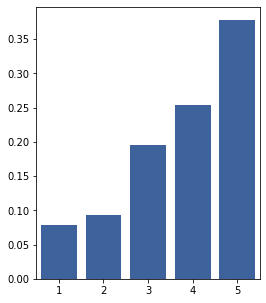

In [4]:
get_data(isbn)

In [5]:
get_reviews(isbn)

https://www.goodreads.com/review/show/6752242?utm_campaign=reviews&utm_medium=widget


https://www.goodreads.com/review/show/4909449656?utm_campaign=reviews&utm_medium=widget


https://www.goodreads.com/review/show/27676082?utm_campaign=reviews&utm_medium=widget


https://www.goodreads.com/review/show/19692450?utm_campaign=reviews&utm_medium=widget


https://www.goodreads.com/review/show/214497728?utm_campaign=reviews&utm_medium=widget


...

https://www.goodreads.com/review/show/721749098?utm_campaign=reviews&utm_medium=widget


https://www.goodreads.com/review/show/1143417350?utm_campaign=reviews&utm_medium=widget


https://www.goodreads.com/review/show/12481771?utm_campaign=reviews&utm_medium=widget


https://www.goodreads.com/review/show/1956921334?utm_campaign=reviews&utm_medium=widget


KeyboardInterrupt: 